In [1]:
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

In [2]:
import numpy as np  # numpy 라이브러리를 np라는 이름으로 불러온다. 배열 처리에 사용한다.

d = np.column_stack((dach_length, dach_height))  # 닥스훈트의 길이 데이터와 높이 데이터를 열 방향으로 붙여서 2차원 데이터로 만든다.
j = np.column_stack((jin_length, jin_height))    # 진돗개의 길이 데이터와 높이 데이터를 열 방향으로 붙여서 2차원 데이터로 만든다.

X = np.concatenate((d, j))   # 닥스훈트 데이터 d와 진돗개 데이터 j를 위아래로 합쳐서 전체 데이터 집합 X를 만든다.

y = [0]*len(d) + [1]*len(j)  # 닥스훈트는 0, 진돗개는 1로 레이블을 만든다.
                              # len(d)개만큼 0을 만들고, len(j)개만큼 1을 만든 뒤 이어 붙인다.

print('dogs :', X)            # 전체 강아지 데이터 X를 출력한다.
print('labels :', y)          # 각 데이터가 어떤 강아지인지 나타내는 레이블 y를 출력한다.

dogs : [[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]]
labels : [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


In [3]:
from sklearn.pipeline import Pipeline          # 여러 전처리/모델 단계를 하나로 묶는 Pipeline을 불러온다.
from sklearn.preprocessing import StandardScaler  # 데이터의 각 특성을 평균 0, 표준편차 1로 표준화하는 도구를 불러온다.
from sklearn.svm import LinearSVC              # 선형 SVM 분류 모델을 불러온다.

svm = Pipeline([                               # 표준화 → 선형 SVM 학습 순서로 실행되는 파이프라인을 만든다.
               ('scaler', StandardScaler()),  # 첫 번째 단계: 입력 데이터 X를 표준화한다.
                                                # 예: 길이와 높이처럼 단위나 범위가 다른 값을 비슷한 스케일로 맞춘다.

               ('linearSVC', LinearSVC(C=1, loss='hinge', dual=True))
                                                # 두 번째 단계: 표준화된 데이터를 이용해 선형 SVM 분류기를 만든다.
                                                # C=1: 오차를 얼마나 허용할지 조절하는 값이다.
                                                # C가 크면 오차를 덜 허용하고, C가 작으면 오차를 더 허용한다.
                                                # loss='hinge': SVM에서 사용하는 hinge loss를 사용한다.
                                                # dual=True: dual problem 형태로 최적화를 수행한다.
])

svm.fit(X, y)                                  # X와 y를 이용해서 SVM 모델을 학습시킨다.
                                                # X: 입력 데이터, 예를 들면 [길이, 높이]
                                                # y: 정답 레이블, 예를 들면 닥스훈트=0, 진돗개=1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linearSVC', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",True
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [4]:
dog_classes = {0:'Dachshund', 1:'Jindo dog'}
# 숫자 레이블을 실제 강아지 이름으로 바꾸기 위한 딕셔너리다.
# 0이면 Dachshund, 1이면 Jindo dog를 의미한다.

data1, data2 = [59, 35], [53, 54]
# 새로 분류해볼 강아지 데이터 2개를 만든다.
# data1은 길이 59, 높이 35인 강아지다.
# data2는 길이 53, 높이 54인 강아지다.
# 즉 각각 [길이, 높이] 형태다.

y_pred = svm.predict([data1])
# 학습된 SVM 모델 svm에게 data1을 분류하게 한다.
# 주의: predict에는 2차원 형태로 넣어야 하므로 [data1]처럼 한 번 더 감싼다.
# data1은 [59, 35]이고, [data1]은 [[59, 35]]다.

print('data :', data1, ', classification:', dog_classes[y_pred[0]])
# data1의 값과 예측된 강아지 종류를 출력한다.
# y_pred[0]은 예측 결과 숫자 레이블이다.
# dog_classes[y_pred[0]]을 통해 0 또는 1을 실제 이름으로 바꾼다.

y_pred = svm.predict([data2])
# 학습된 SVM 모델 svm에게 data2를 분류하게 한다.
# 마찬가지로 predict에는 [[53, 54]] 형태로 들어간다.

print('data :', data2, ', classification:', dog_classes[y_pred[0]])
# data2의 값과 예측된 강아지 종류를 출력한다.
# 예측 결과가 0이면 Dachshund, 1이면 Jindo dog가 출력된다.

data : [59, 35] , classification: Dachshund
data : [53, 54] , classification: Jindo dog


### Build an SVM machine using scikit-learn Pipeline

### Using SVM for larger datasets

In [5]:
import pandas as pd
import numpy as np

data_loc = 'https://github.com/dongupak/DataML/raw/main/csv/'
df = pd.read_csv(data_loc + 'two_classes.csv')
df.tail(3)

,x1,x2,y
997,-4.634470,0.300158,0
998,1.426275,-2.765590,1
999,1.988053,1.466494,1


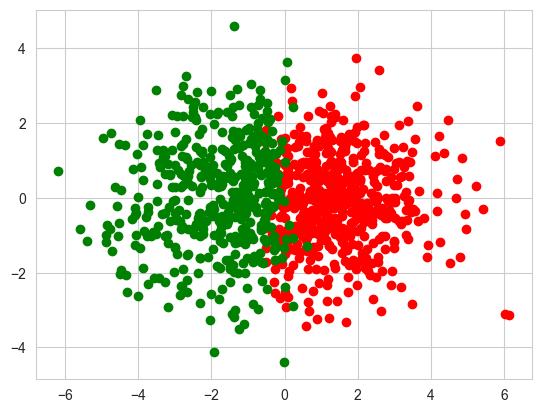

In [7]:
df_positive = df[df['y']==1]     # y가 1인 데이터만 추출
df_negative = df[df['y']==0]     # y가 0인 데이터만 추출
import matplotlib.pyplot as plt
plt.scatter(df_positive['x1'], df_positive['x2'], color='r')
plt.scatter(df_negative['x1'], df_negative['x2'], color='g')

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
X = df[['x1', 'x2']].to_numpy()           # x1, x2 are the input features
y = df['y']                               # y is the target label
svm = Pipeline([  # standard scaler, linear SVM classifier
                ('scaler', StandardScaler()),
                ('linearSVC', LinearSVC(C=1, loss='hinge', dual='auto'))
])
svm.fit(X, y)     # learn a svm model with X, y inputs

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linearSVC', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [9]:
svm.predict([[0.12, 0.56], [-4, 40], [0, 40], [5,20]])

array([1, 0, 0, 1])

In [9]:
svm.named_steps['linearSVC'].coef_

array([[ 5.79479658, -0.14501124]])

### kernel SVM

Text(0.5, 1.0, 'XOR')

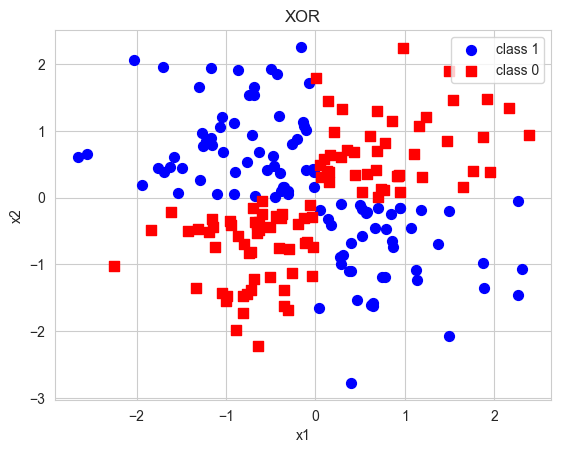

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c='b', marker='o', label='class 1', s=50)
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
            c='r', marker='s', label='class 0', s=50)
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR")

### Visualization of the SVM results

In [11]:
import matplotlib as mpl
# matplotlib 라이브러리 전체를 mpl이라는 이름으로 불러온다.
# 여기서는 색상맵(cmap)을 사용하기 위해 필요하다.


def plot_xor(X, y, model, title, xmin=-3, xmax=3, ymin=-3, ymax=3):
    # XOR 데이터를 시각화하는 함수다.
    # X: 입력 데이터, 보통 [x1, x2] 형태의 2차원 데이터
    # y: 정답 레이블, 0 또는 1
    # model: 학습된 분류 모델
    # title: 그래프 제목
    # xmin, xmax: x축 범위
    # ymin, ymax: y축 범위

    XX, YY = np.meshgrid(
        np.arange(xmin, xmax, (xmax-xmin)/1000),
        np.arange(ymin, ymax, (ymax-ymin)/1000)
    )
    # 그래프 전체 영역을 촘촘한 격자점으로 만든다.
    # np.arange(xmin, xmax, (xmax-xmin)/1000)는 x축 방향으로 1000개 정도의 점을 만든다.
    # np.arange(ymin, ymax, (ymax-ymin)/1000)는 y축 방향으로 1000개 정도의 점을 만든다.
    # np.meshgrid는 x좌표 배열과 y좌표 배열을 조합해서 2차원 격자 좌표를 만든다.
    # XX에는 각 격자점의 x좌표들이 들어간다.
    # YY에는 각 격자점의 y좌표들이 들어간다.

    ZZ = np.reshape(
        model.predict(np.array([XX.ravel(), YY.ravel()]).T),
        XX.shape
    )
    # 격자점 하나하나에 대해 모델이 어느 클래스로 예측하는지 계산한다.
    # XX.ravel()은 2차원 XX 배열을 1차원으로 펼친다.
    # YY.ravel()도 2차원 YY 배열을 1차원으로 펼친다.
    # np.array([XX.ravel(), YY.ravel()])는 x좌표 목록과 y좌표 목록을 하나로 묶는다.
    # .T는 전치(transpose)로, [[x1, y1], [x2, y2], ...] 형태로 바꾼다.
    # model.predict(...)는 각 격자점의 클래스를 예측한다.
    # np.reshape(..., XX.shape)는 예측 결과를 다시 XX와 같은 2차원 모양으로 바꾼다.
    # ZZ에는 각 격자점의 예측 클래스가 들어간다.

    plt.contourf(XX, YY, ZZ, cmap=mpl.cm.Paired_r, alpha=0.5)
    # 모델이 예측한 분류 영역을 색으로 칠한다.
    # XX, YY는 격자 좌표이고, ZZ는 각 위치에서의 예측 클래스다.
    # cmap=mpl.cm.Paired_r는 색상 조합을 지정한다.
    # alpha=0.5는 색을 반투명하게 만든다는 뜻이다.

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        c='b',
        marker='o',
        label='class 1',
        s=50
    )
    # 실제 데이터 중 y가 1인 점들만 그래프에 찍는다.
    # X[y == 1, 0]은 class 1 데이터들의 x1 값이다.
    # X[y == 1, 1]은 class 1 데이터들의 x2 값이다.
    # c='b'는 파란색으로 표시한다는 뜻이다.
    # marker='o'는 동그라미 모양으로 표시한다는 뜻이다.
    # label='class 1'은 범례에 표시될 이름이다.
    # s=50은 점 크기다.

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        c='r',
        marker='s',
        label='class 0',
        s=50
    )
    # 실제 데이터 중 y가 0인 점들만 그래프에 찍는다.
    # X[y == 0, 0]은 class 0 데이터들의 x1 값이다.
    # X[y == 0, 1]은 class 0 데이터들의 x2 값이다.
    # c='r'은 빨간색으로 표시한다는 뜻이다.
    # marker='s'는 네모 모양으로 표시한다는 뜻이다.
    # label='class 0'은 범례에 표시될 이름이다.
    # s=50은 점 크기다.

    plt.xlim(xmin, xmax)
    # x축 범위를 xmin부터 xmax까지로 설정한다.

    plt.ylim(ymin, ymax)
    # y축 범위를 ymin부터 ymax까지로 설정한다.

    plt.title(title)
    # 그래프 제목을 설정한다.

    plt.xlabel("x1")
    # x축 이름을 x1로 설정한다.

    plt.ylabel("x2")
    # y축 이름을 x2로 설정한다.


from sklearn.svm import SVC
# SVM 분류 모델인 SVC를 불러온다.
# SVC는 커널을 사용해서 선형/비선형 분류를 할 수 있다.

from sklearn.metrics import accuracy_score
# 예측 정확도를 계산하는 accuracy_score 함수를 불러온다.


linsvc = SVC(kernel="linear").fit(X_xor, y_xor)
# 선형 커널을 사용하는 SVM 모델을 만든다.
# kernel="linear"는 직선으로 데이터를 분류한다는 뜻이다.
# fit(X_xor, y_xor)는 XOR 데이터 X_xor와 정답 y_xor를 이용해 모델을 학습시킨다.
# 학습된 모델은 linsvc에 저장된다.

polysvc = SVC(kernel="poly", degree=2, gamma=1, coef0=0).fit(X_xor, y_xor)
# 다항식 커널을 사용하는 SVM 모델을 만든다.
# kernel="poly"는 polynomial kernel, 즉 다항식 커널을 사용한다는 뜻이다.
# degree=2는 2차 다항식 커널을 사용한다는 뜻이다.
# gamma=1은 커널 함수에서 데이터 영향 범위를 조절하는 값이다.
# coef0=0은 다항식 커널의 상수항을 설정하는 값이다.
# fit(X_xor, y_xor)는 XOR 데이터로 모델을 학습시킨다.
# 학습된 모델은 polysvc에 저장된다.

rbfsvc = SVC(kernel="rbf").fit(X_xor, y_xor)
# RBF 커널을 사용하는 SVM 모델을 만든다.
# kernel="rbf"는 radial basis function 커널을 사용한다는 뜻이다.
# RBF 커널은 비선형 경계선을 만들 수 있어서 XOR 같은 데이터를 잘 분류할 수 있다.
# fit(X_xor, y_xor)는 XOR 데이터로 모델을 학습시킨다.
# 학습된 모델은 rbfsvc에 저장된다.


print('linear SVM accuracy: ', accuracy_score(y_xor, linsvc.predict(X_xor)))
# 선형 SVM의 정확도를 출력한다.
# linsvc.predict(X_xor)는 X_xor에 대한 예측 결과를 만든다.
# accuracy_score(y_xor, 예측값)는 실제 정답 y_xor와 예측값을 비교해서 정확도를 계산한다.

print('polynomial SVM accuracy: ', accuracy_score(y_xor, polysvc.predict(X_xor)))
# 다항식 커널 SVM의 정확도를 출력한다.
# polysvc.predict(X_xor)는 X_xor에 대한 예측 결과를 만든다.
# accuracy_score는 실제 정답과 예측값이 얼마나 일치하는지 계산한다.

print('rbf SVM accuracy: ', accuracy_score(y_xor, rbfsvc.predict(X_xor)))
# RBF 커널 SVM의 정확도를 출력한다.
# rbfsvc.predict(X_xor)는 X_xor에 대한 예측 결과를 만든다.
# accuracy_score는 실제 정답과 예측값을 비교해서 정확도를 계산한다.

linear SVM accuracy:  0.67
polynomial SVM accuracy:  0.96
rbf SVM accuracy:  0.985


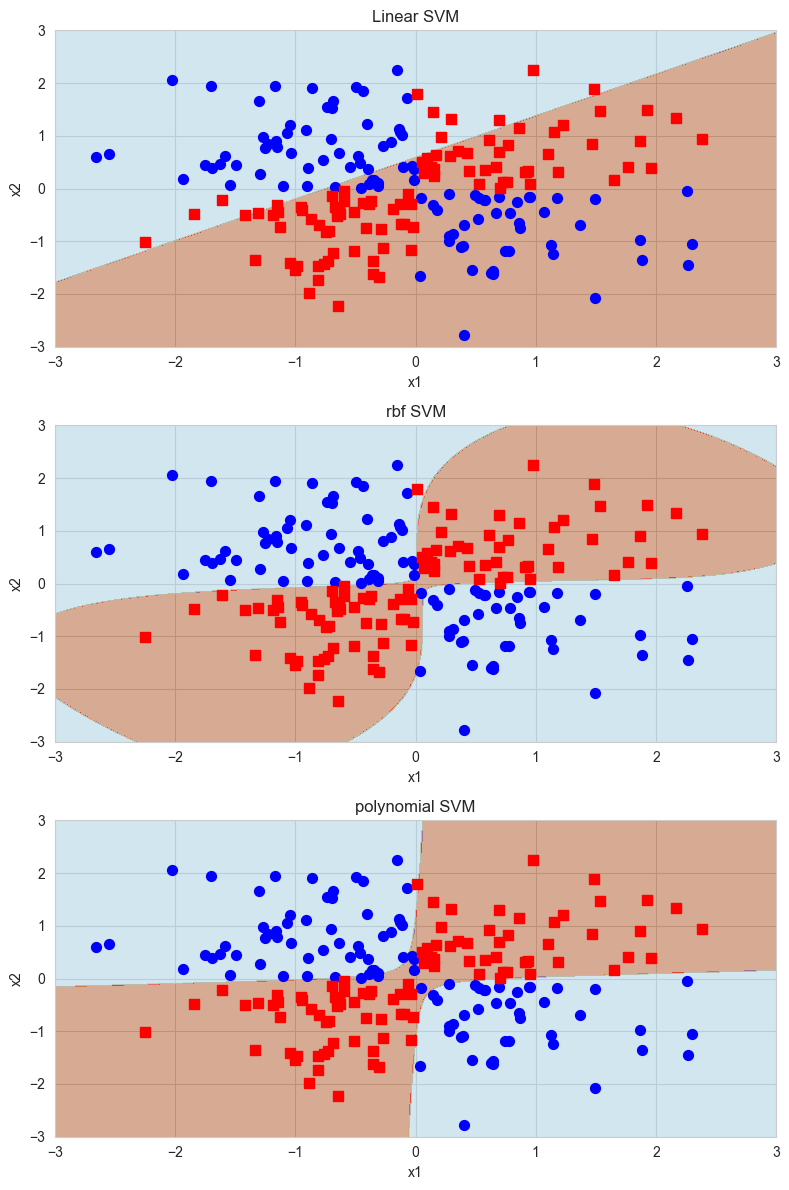

In [12]:
plt.figure(figsize=(8, 12))
plt.subplot(311)
plot_xor(X_xor, y_xor, linsvc, "Linear SVM")
plt.subplot(312)
plot_xor(X_xor, y_xor, rbfsvc, "rbf SVM")
plt.subplot(313)
plot_xor(X_xor, y_xor, polysvc, "polynomial SVM")
plt.tight_layout()